# Previsão de Rendimento de Safra — FarmTech Solutions

Uma fazenda de 200 hectares produz múltiplas culturas (cacau, palma, arroz, borracha). É necessário prever o **rendimento em toneladas/hectare** a partir das condições climáticas e de umidade registradas e, com isso, identificar padrões de produtividade (tendências e cenários discrepantes) para apoiar decisões de gestão agrícola.

**Base de dados:** `crop_yield.csv` — histórico de precipitação, umidade específica e relativa, temperatura e rendimento por cultura.

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Modelos e Métricas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_squared_error, mean_absolute_error, r2_score

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR


# Configurações Visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e visão inicial da base

In [22]:
# Carregamento da base
df = pd.read_csv('data/crop_yield.csv')

# Visão geral: dimensão, primeiras linhas e tipos
print(f"{df.shape[0]} linhas e {df.shape[1]} colunas")
print()
display(df.head())
print()
df.info()


156 linhas e 6 colunas



,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


### 2.1 Análise Visual das Variáveis

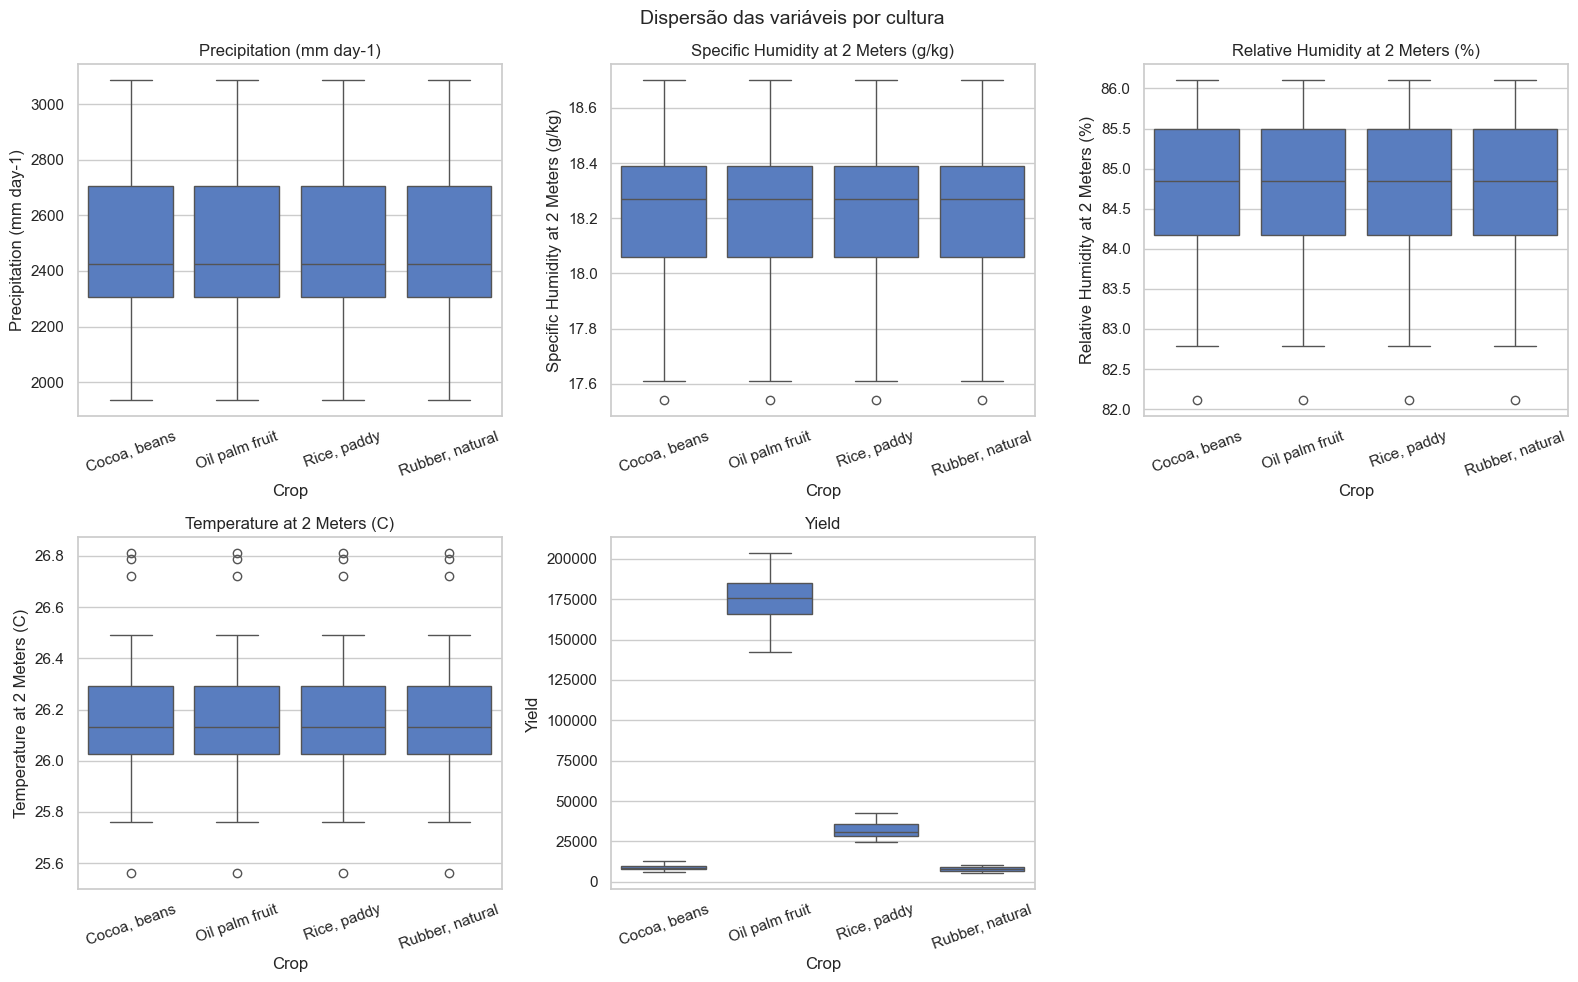

In [24]:
# Dispersão das 5 variáveis por cultura

vars_plot = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
             'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle('Dispersão das variáveis por cultura', fontsize=14)

for i, col in enumerate(vars_plot):
    sns.boxplot(ax=axes[i], data=df, x='Crop', y=col)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)

axes[5].set_visible(False)
plt.tight_layout()
plt.show()

**Análise exploratória e prévia de outliers**

Pelos boxplots acima:

- **Precipitação:** dispersão similar entre culturas; sem outliers aparentes.
- **Umidade específica e relativa:** pontos abaixo dos whiskers em todas as culturas — possíveis outliers de *baixa umidade*.
- **Temperatura:** pontos tanto acima quanto abaixo dos whiskers — possíveis outliers de temperatura extrema.
- **Yield:** grande diferença entre culturas (Palma > Arroz > Cacau/Borracha); dentro de cada cultura, sem outliers evidentes.

Como as variáveis climáticas se repetem para as quatro culturas, os outliers tendem a coincidir nos mesmos registros. O bloco 2.2 valida e identifica essas observações de forma objetiva.

### 2.2 Validação e identificação de outliers


=== Cocoa, beans ===
  Specific Humidity at 2 Meters (g/kg): 1 outliers (limites: 17.57 – 18.88)
  Relative Humidity at 2 Meters (%): 1 outliers (limites: 82.20 – 87.47)
  Temperature at 2 Meters (C): 4 outliers (limites: 25.63 – 26.69)


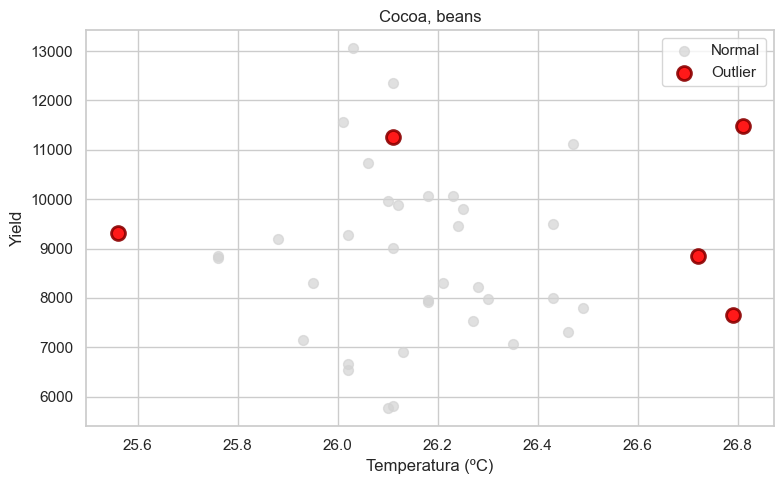


=== Oil palm fruit ===
  Specific Humidity at 2 Meters (g/kg): 1 outliers (limites: 17.57 – 18.88)
  Relative Humidity at 2 Meters (%): 1 outliers (limites: 82.20 – 87.47)
  Temperature at 2 Meters (C): 4 outliers (limites: 25.63 – 26.69)


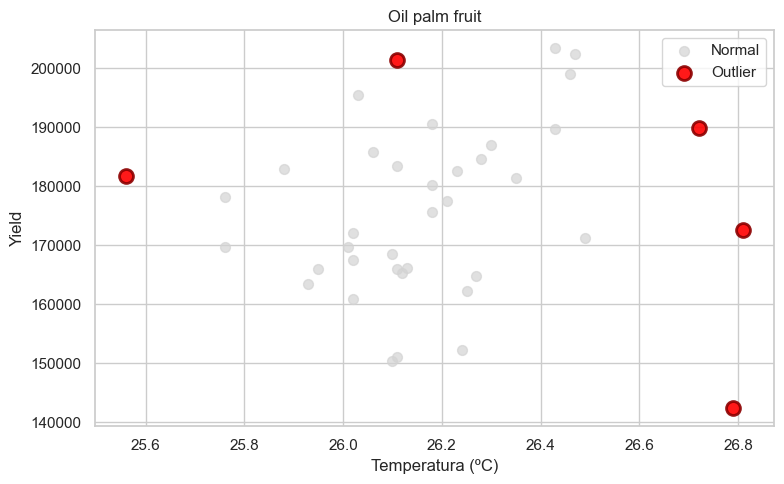


=== Rice, paddy ===
  Specific Humidity at 2 Meters (g/kg): 1 outliers (limites: 17.57 – 18.88)
  Relative Humidity at 2 Meters (%): 1 outliers (limites: 82.20 – 87.47)
  Temperature at 2 Meters (C): 4 outliers (limites: 25.63 – 26.69)


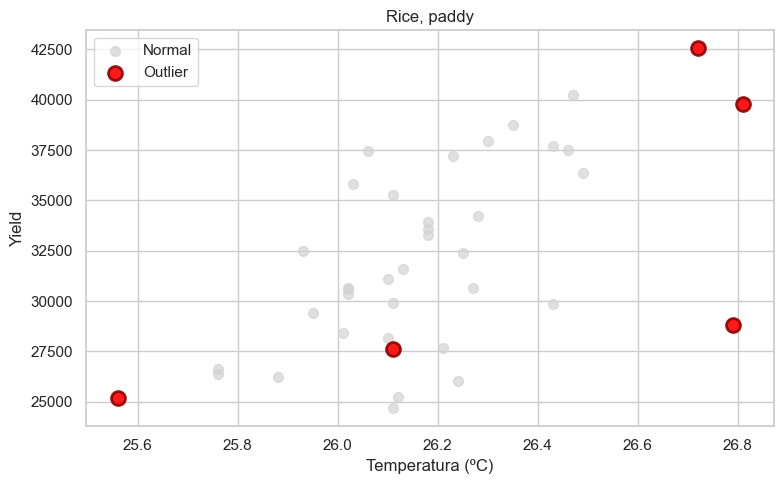


=== Rubber, natural ===
  Specific Humidity at 2 Meters (g/kg): 1 outliers (limites: 17.57 – 18.88)
  Relative Humidity at 2 Meters (%): 1 outliers (limites: 82.20 – 87.47)
  Temperature at 2 Meters (C): 4 outliers (limites: 25.63 – 26.69)


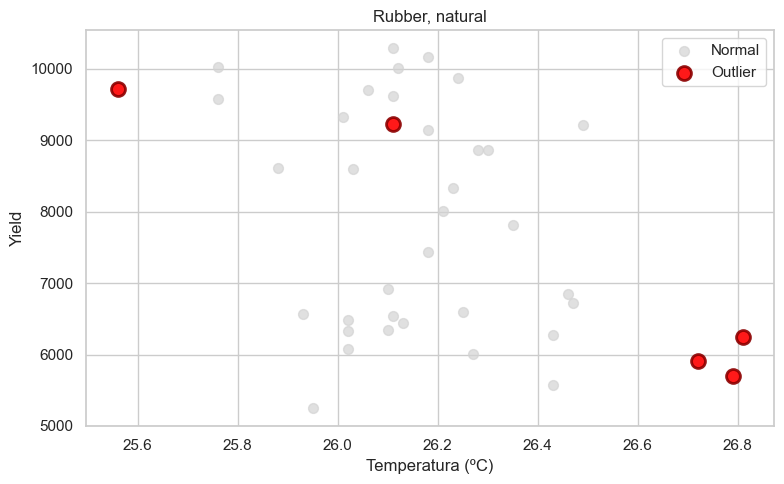


RESUMO DA ANÁLISE DE OUTLIERS
• Cocoa, beans: 5/39 outliers (12.8%)
• Oil palm fruit: 5/39 outliers (12.8%)
• Rice, paddy: 5/39 outliers (12.8%)
• Rubber, natural: 5/39 outliers (12.8%)

Total geral: 20/156 registros (12.8%)


In [30]:
# Método IQR por cultura (1.5 * IQR calculados dentro de cada Crop)
cols_num = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
            'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Yield']

outlier_cols = {col: pd.Series(False, index=df.index) for col in cols_num}
resumo_culturas = []

for crop in df['Crop'].unique():
    mask_crop = df['Crop'] == crop
    crop_outlier_mask = pd.Series(False, index=df.index)
    print(f"\n=== {crop} ===")
    for col in cols_num:
        vals = df.loc[mask_crop, col]
        Q1, Q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        out_mask = mask_crop & ((df[col] < lb) | (df[col] > ub))
        outlier_cols[col] = outlier_cols[col] | out_mask
        crop_outlier_mask = crop_outlier_mask | out_mask
        if out_mask.sum() > 0:
            print(f"  {col}: {out_mask.sum()} outliers (limites: {lb:.2f} – {ub:.2f})")
    n_crop_out = crop_outlier_mask.sum()
    resumo_culturas.append((crop, n_crop_out, mask_crop.sum()))
    
    # Gráfico da cultura (Temperatura x Yield)
    df_crop = df[mask_crop].copy()
    df_crop['_out'] = crop_outlier_mask[mask_crop].values
    df_n = df_crop[~df_crop['_out']]
    df_o = df_crop[df_crop['_out']]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_n['Temperature at 2 Meters (C)'], df_n['Yield'], c='lightgray', s=50, alpha=0.7, label='Normal')
    if len(df_o) > 0:
        ax.scatter(df_o['Temperature at 2 Meters (C)'], df_o['Yield'], c='red', s=100, alpha=0.9, edgecolors='darkred', linewidths=2, label='Outlier')
    ax.set_xlabel('Temperatura (ºC)')
    ax.set_ylabel('Yield')
    ax.set_title(f'{crop}')
    ax.legend()
    plt.tight_layout()
    plt.show()

# Marcar coluna outlier no df (para uso posterior na modelagem)
df['outlier'] = pd.concat(outlier_cols, axis=1).any(axis=1)
df_out = df[df['outlier']].copy()
df_out['Motivo'] = df_out.index.map(lambda i: ', '.join([col for col in cols_num if outlier_cols[col].loc[i]]))

# Resumo da análise com base nos gráficos
print("\n" + "="*50)
print("RESUMO DA ANÁLISE DE OUTLIERS")
print("="*50)
for crop, n_out, n_total in resumo_culturas:
    pct = 100 * n_out / n_total if n_total > 0 else 0
    print(f"• {crop}: {n_out}/{n_total} outliers ({pct:.1f}%)")
print(f"\nTotal geral: {df['outlier'].sum()}/{len(df)} registros ({100*df['outlier'].sum()/len(df):.1f}%)")

## 3. Clusterização e Tendências (Não-Supervisionado)
De acordo com o cap 10., aplicaremos um método Não-Supervisionado para segmentar e encontrar padrões ocultos de produtividade (rendimento x clima) das plantações. Utilizaremos o **K-Means**.

In [ ]:
# Para o KMeans, vamos focar no Rendimento e nas Chuvas (que mostraram alguma influência cruzada)
features_cluster = df[['Precipitation (mm day-1)', 'Temperature at 2 Meters (C)', 'Yield']]

# É fundamental padronizar antes de usar o K-Means
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_cluster)

# Testando pelo método do cotovelo para validar número de Clusters K ótimo
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(features_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método do Cotovelo (Elbow Method)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.show()

# Definindo K=3 (Ex: Baixo, Médio, Alto rendimento/condições)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(features_scaled)

# Visualizando os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Precipitation (mm day-1)', y='Yield', hue='Cluster', palette='Set1', style='Crop')
plt.title('Clusters de Plantações: Chuva x Rendimento')
plt.show()

## 4. Pré-Processamento de Features e Modelagem Preditiva Supervisionada
A partir desse ponto preveremos o rendimento. Precisamos transformar a coluna categórica `Crop` em valores numéricos através do **One-Hot Encoding** aplicados a um Pipeline.

In [ ]:
# Variáveis Independentes (X) e Alvo (y)
X = df.drop(columns=['Yield', 'Cluster', 'outlier'])  # Cluster e outlier apenas descritivos
y = df['Yield']

# Identificando as colunas numéricas e a categórica
num_features = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)', 
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
cat_features = ['Crop']

# Transformador customizado para limpar e normatizar no Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
    ])

# Dividindo entre bases de Treinamento (80%) e Testes (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Instâncias de Treino: {X_train.shape[0]}")
print(f"Instâncias de Teste: {X_test.shape[0]}")

### 4.1 Treinamento de 5 Algoritmos Diferentes de Machine Learning
1. **Regressão Linear Múltipla** (Base simples)
2. **Decision Tree Regressor** (Mapeamento não linear de decisão)
3. **Random Forest Regressor** (Ensambles de múltiplas árvores)
4. **SVR - Support Vector Regressor** (Vetores de Suporte de hiperplano)
5. **Gradient Boosting Regressor** (Árvores em Sequência focadas no erro)

In [ ]:
# Dicionário contendo os 5 modelos
models_dict = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor (SVR)": SVR(kernel='linear'),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
metrics_df = pd.DataFrame(columns=['Modelo', 'R2 Score', 'RMSE', 'MAE'])

# Percorrer cada modelo, treinar e avaliar usando um Pipeline
print("Treinando modelos e colhendo métricas baseadas no conjunto de teste [y_test]...\n")

for name, model in models_dict.items():
    # Encadeia o pré-processamento (HotEncoder + Scaler) com o estimador
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    
    # Ajuste e predição
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Calculando as métricas de performance
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Armazenando
    results.append({'Modelo': name, 'R2 Score': r2, 'RMSE': rmse, 'MAE': mae})

metrics_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(metrics_df.style.background_gradient(cmap='Greens', subset=['R2 Score']))

## 5. Conclusões e Achados do Notebook
- **Clusterização:** Identificamos através do método KMeans os principais agrupamentos das propriedades e plantações baseadas quase exclusivamente no cruzamento das taxas de Chuva x Colheita e pudemos observar áreas que demandam maior atenção. Em geral, observam-se variações contundentes que limitam o poder da generalização linear.
- **Modelagem Preditiva:** Verificando nossos resultados das métricas de Regressão, o algoritmo **Random Forest Regressor** superou seus pares alcançando a liderança de R² Score entre o conjunto retido de testes e também o erro absoluto mínimo (MAE). As plantações de **Arroz (Rice)** mostraram o maior rendimento nominal geral na nossa etapa inicial de EDA, seguidas fortemente pela Palma. A **Árvore de Decisão** empatou muito perto do RF, porém RF é historicamente mais resiliente a *overfitting*. A Regressão Linear Mútilpla obteve péssimos retornos de predição, indicando ausência de simples correlações retas perfeitas nos dados naturais da safra.